In [112]:
import warnings
warnings.filterwarnings(action='ignore')

In [113]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [114]:
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [115]:
df = pd.read_csv('concrete_data.csv')

In [116]:
print("First 5 Rows:")
display(df.head())

First 5 Rows:


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [117]:
X, y = df.iloc[:,:-1], df.iloc[:,-1]

In [118]:
print("Input Columns: Features")
display(X)
print("Output Column: Target")
display(y)

Input Columns: Features


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360
...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28


Output Column: Target


0       79.99
1       61.89
2       40.27
3       41.05
4       44.30
        ...  
1025    44.28
1026    31.18
1027    23.70
1028    32.77
1029    32.40
Name: Strength, Length: 1030, dtype: float64

In [119]:
# Prepare data for box-cox transformation
X_boxcox = X.copy()
for col in X_boxcox.columns:
    if (X_boxcox[col] == 0).any():
        print(f"Adding small constant to {col} (contains zeros)")
        X_boxcox[col] = X_boxcox[col] + 1e-6

Adding small constant to Blast Furnace Slag (contains zeros)
Adding small constant to Fly Ash (contains zeros)
Adding small constant to Superplasticizer (contains zeros)


In [120]:
X_train, X_test, y_train, y_test = train_test_split(X_boxcox, y, test_size=0.2, random_state=42)

In [121]:
print("Train-Test-Split")
print("="*25)
print(f"X_train Shape: {X_train.shape[0]} samples")
print(f"X_test Shape: {X_test.shape[0]} samples")
print(f"X_train(%): {X_train.shape[0]/X.shape[0]:.1%}")
print(f"X_test(%): {X_test.shape[0]/X.shape[0]:.1%}")

Train-Test-Split
X_train Shape: 824 samples
X_test Shape: 206 samples
X_train(%): 80.0%
X_test(%): 20.0%


In [122]:
# Apply boxcox transform
print("\nApplying Box-Cox transformation...")
boxcox_transformer = PowerTransformer(method='box-cox', standardize=False)
X_train_boxcox = boxcox_transformer.fit_transform(X_train)
X_test_boxcox = boxcox_transformer.transform(X_test)

# Convert back to DataFrame with COLUMN NAMES
X_train_boxcox = pd.DataFrame(X_train_boxcox, columns=X.columns, index=X_train.index)
X_test_boxcox = pd.DataFrame(X_test_boxcox, columns=X.columns, index=X_test.index)
print("✓ Box-Cox transformation completed!")


Applying Box-Cox transformation...
✓ Box-Cox transformation completed!


In [123]:
# Apply yeo-johnson transform
print("\nApplying Yeo-Johnson transformation...")
yeojohnson_transformer = PowerTransformer(method='yeo-johnson', standardize=False)
X_train_yeojohnson = yeojohnson_transformer.fit_transform(X_train)
X_test_yeojohnson = yeojohnson_transformer.transform(X_test)

# Convert back to DataFrame with COLUMN NAMES
X_train_yeojohnson = pd.DataFrame(X_train_yeojohnson, columns=X.columns, index=X_train.index)
X_test_yeojohnson = pd.DataFrame(X_test_yeojohnson, columns=X.columns, index=X_test.index)
print("✓ Yeo-Johnson transformation completed!")


Applying Yeo-Johnson transformation...
✓ Yeo-Johnson transformation completed!


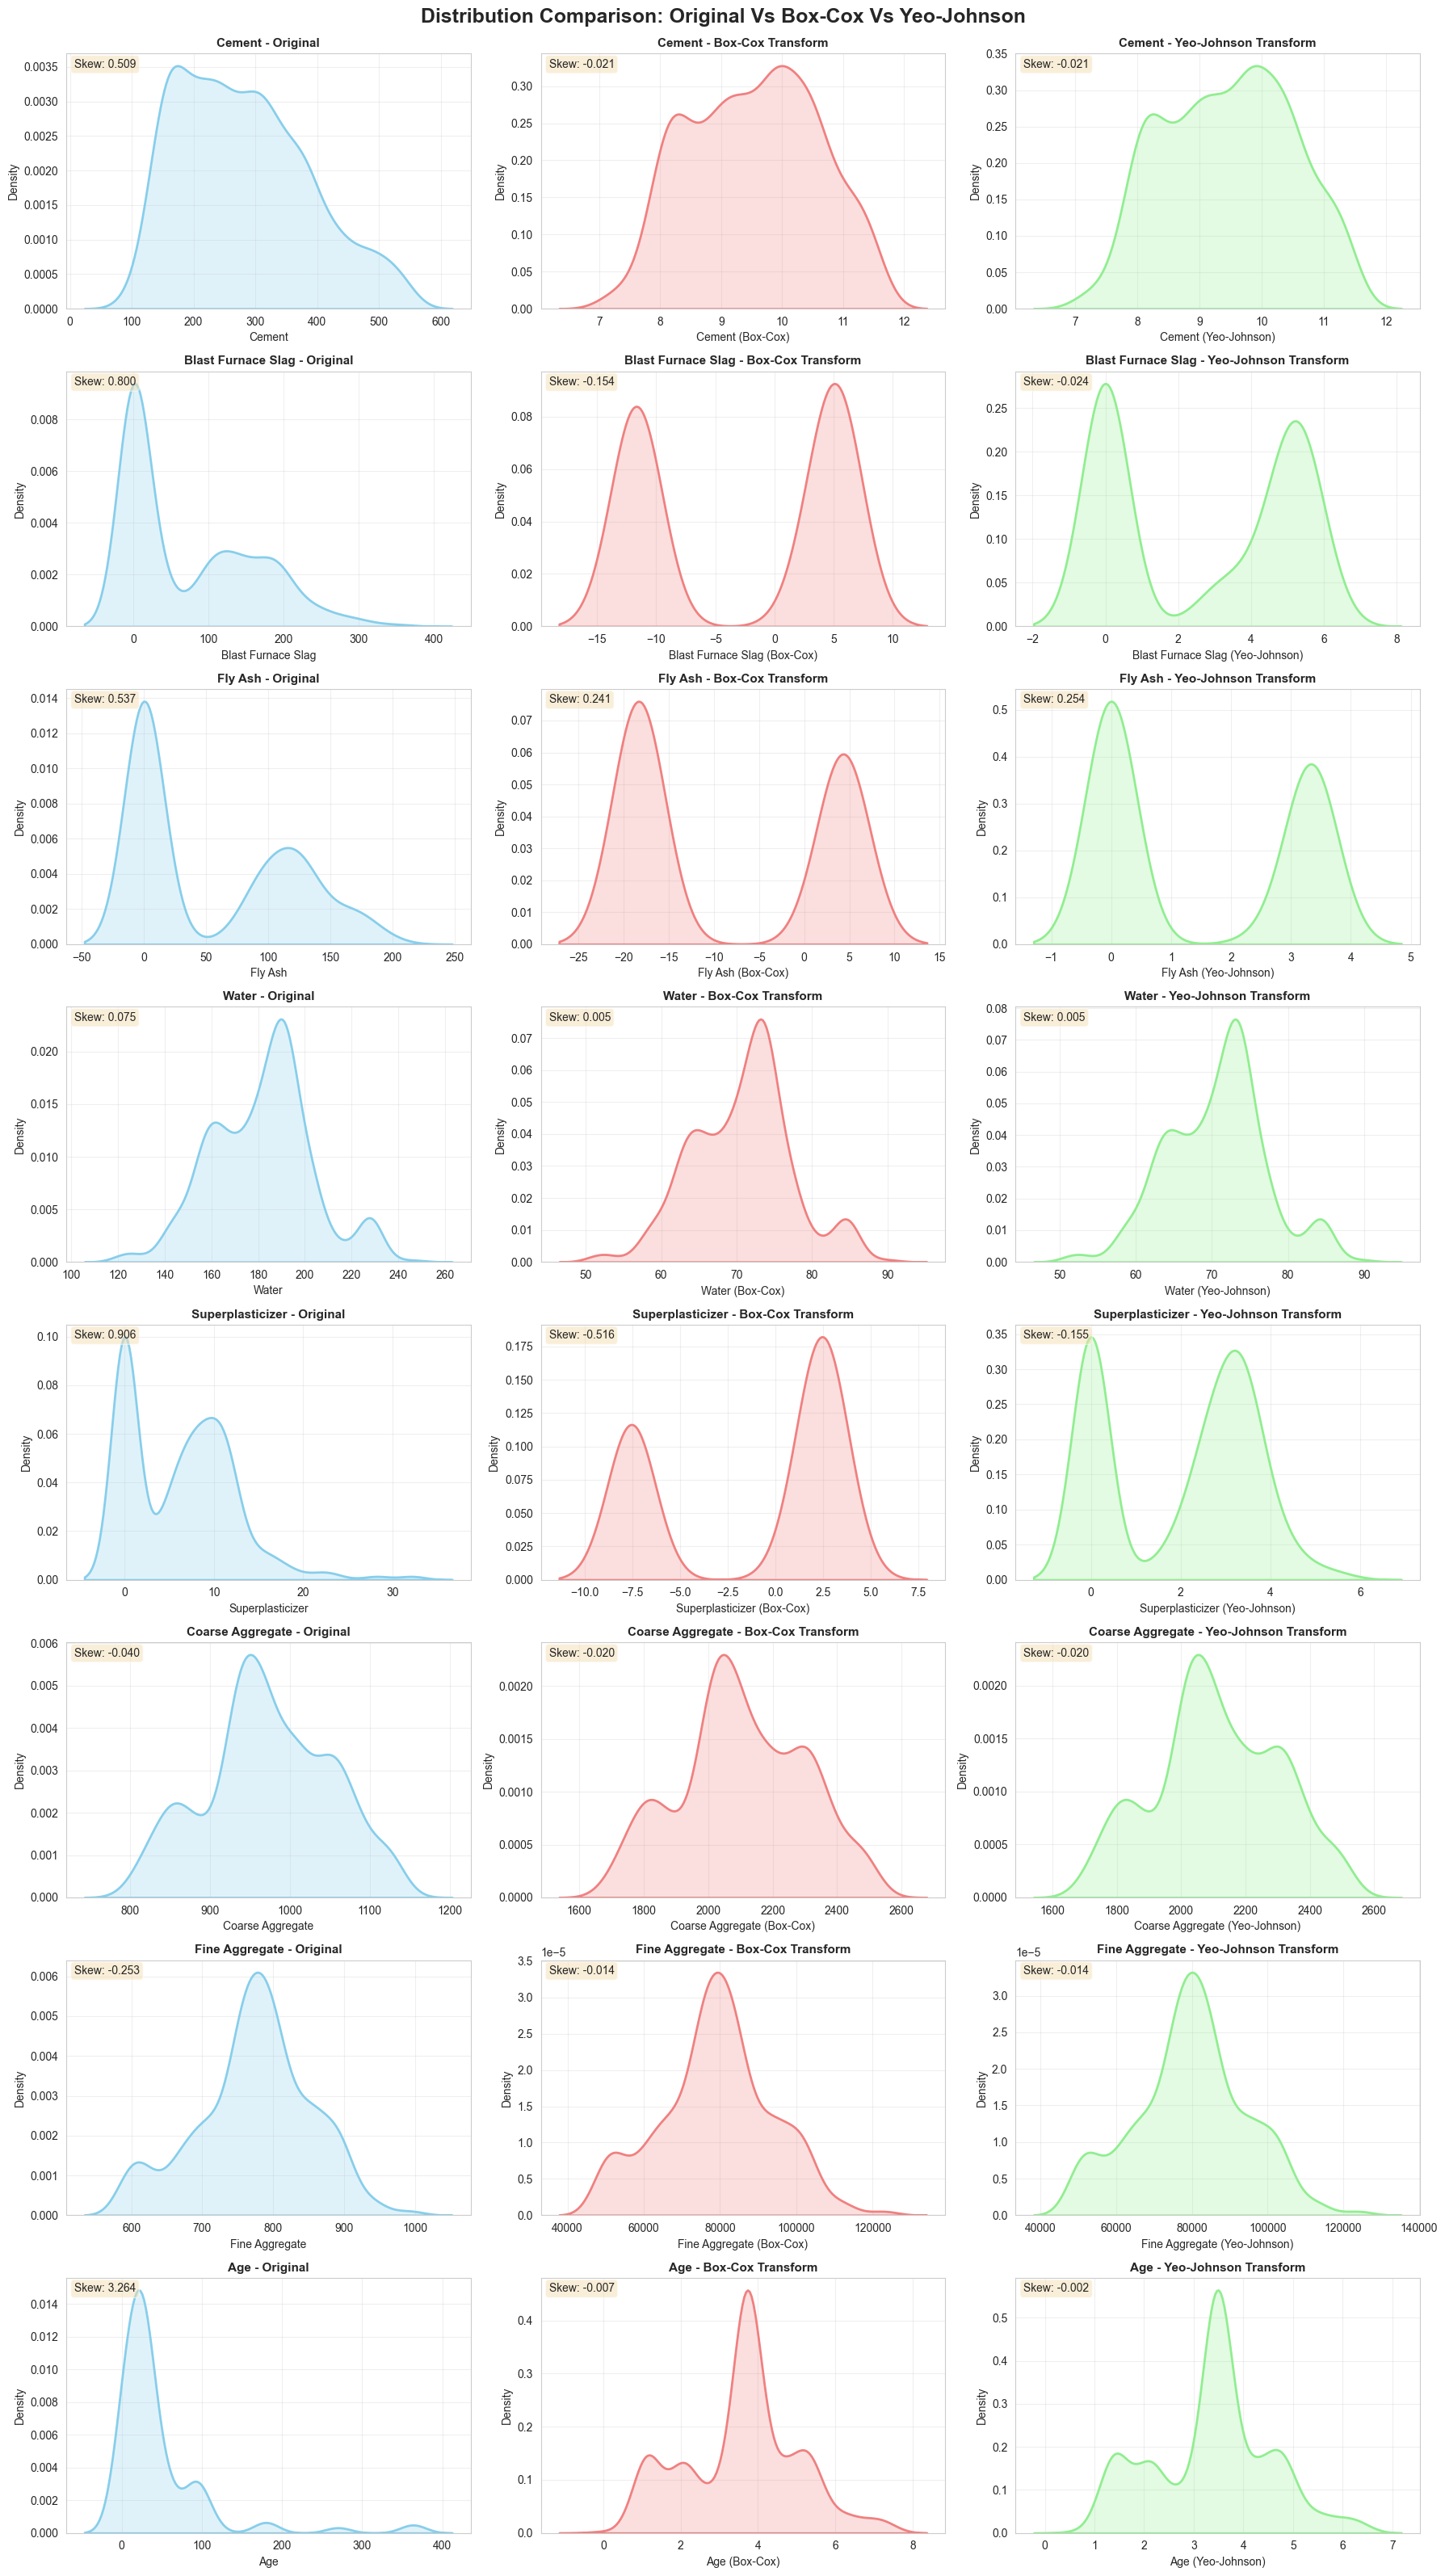

In [124]:
# Visualize Distribution: Original Vs Box-Cox Vs Yeo-Johnson
n_features = len(X.columns)
fig, axes = plt.subplots(n_features, 3, figsize=(18, 4*n_features))
fig.suptitle('Distribution Comparison: Original Vs Box-Cox Vs Yeo-Johnson', 
             fontsize=18, fontweight='bold', y=0.995)

for idx, col in enumerate(X.columns):
    # Original Distribution
    sns.kdeplot(data=X[col], fill=True, color='skyblue', ax=axes[idx, 0], linewidth=2)
    axes[idx, 0].set_title(f'{col} - Original', fontsize=11, fontweight='bold')
    axes[idx, 0].set_xlabel(col)
    axes[idx, 0].set_ylabel('Density')
    axes[idx, 0].grid(alpha=0.3)
    
    # Add Skewness text
    skew_orig = stats.skew(X[col])
    axes[idx, 0].text(0.02, 0.98, f'Skew: {skew_orig:.3f}',  # FIXED: skew_orig not skew_origin
                     transform=axes[idx, 0].transAxes,
                     verticalalignment='top',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # BoxCox transformed
    sns.kdeplot(data=X_train_boxcox[col], fill=True, color='lightcoral', 
                ax=axes[idx, 1], linewidth=2)
    axes[idx, 1].set_title(f'{col} - Box-Cox Transform', fontsize=11, fontweight='bold')
    axes[idx, 1].set_xlabel(f'{col} (Box-Cox)')
    axes[idx, 1].set_ylabel('Density')
    axes[idx, 1].grid(alpha=0.3)
    
    # Add Skewness text
    skew_bc = stats.skew(X_train_boxcox[col])  # FIXED: Use skew_bc
    axes[idx, 1].text(0.02, 0.98, f'Skew: {skew_bc:.3f}',  # FIXED: Use skew_bc
                     transform=axes[idx, 1].transAxes,
                     verticalalignment='top',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # YeoJohnson transformed
    sns.kdeplot(data=X_train_yeojohnson[col], fill=True, color='lightgreen', 
                ax=axes[idx, 2], linewidth=2)
    axes[idx, 2].set_title(f'{col} - Yeo-Johnson Transform', fontsize=11, fontweight='bold')
    axes[idx, 2].set_xlabel(f'{col} (Yeo-Johnson)')
    axes[idx, 2].set_ylabel('Density')
    axes[idx, 2].grid(alpha=0.3)
    
    # Add Skewness text
    skew_yj = stats.skew(X_train_yeojohnson[col])  # FIXED: Use skew_yj
    axes[idx, 2].text(0.02, 0.98, f'Skew: {skew_yj:.3f}',  # FIXED: Use skew_yj
                     transform=axes[idx, 2].transAxes,
                     verticalalignment='top',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()